# Project name --> House price prediction
* Goal of our project --> We give some different data for our diferent feature after that the system predict best prediction.
* In  which algorithm you want to use? --> We want to use from Linear regression.
* Do we want to use from scikit-learn --> Yes.
 

In [2]:
# Now we import our useful libraries.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import tkinter as tk


In [3]:
df = pd.read_csv(r"F:\درس های هوش مصنوعی\Artificial intellence With Musa Rasa\DATA_SETS\house_prices_dataset.csv")
df.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


In [4]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1999.147496,4.49510,49.516900,15.362148,263011.571609
std,501.021194,1.71116,28.992336,8.325101,98336.945117
min,500.000000,2.00000,0.000000,1.000161,-95613.138249
25%,1663.704735,3.00000,24.000000,8.121636,196791.510684
50%,1998.702512,4.00000,49.000000,15.403146,262497.361236
75%,2335.540444,6.00000,75.000000,22.447530,330445.581908
max,3963.118853,7.00000,99.000000,29.993892,660168.255648


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [6]:
type(df) 

pandas.core.frame.DataFrame

In [7]:
df.isna().sum()

square_feet             0
num_rooms               0
age                     0
distance_to_city(km)    0
price                   0
dtype: int64

In [8]:
df = df.dropna()

"""
   Dropna has two parameter:
   0: Drop Row which contain missing value
   1: Srop Column which contain missing value
"""
df.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


<Axes: >

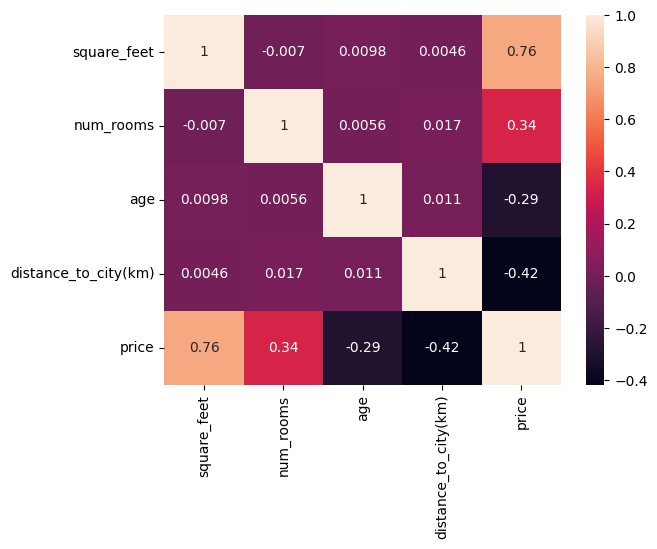

In [9]:
corr = df.corr()
sns.heatmap(corr,annot=True)

* Also you can see to the dataset we have two feature which they have not very effictive to the predicion in this case I want to remove these feature's.

In [10]:
# Drop ineffictive feature's
df = df.drop(['age','distance_to_city(km)'],axis = 1)


<Axes: >

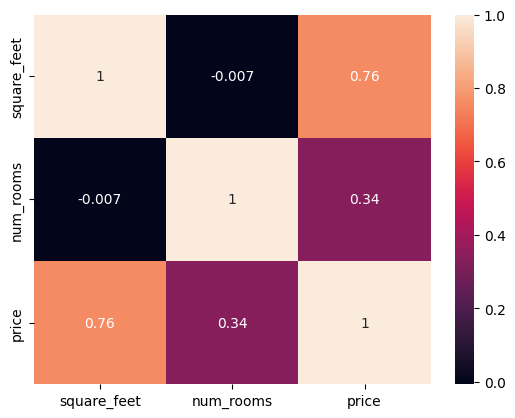

In [11]:
corr = df.corr()
sns.heatmap(corr,annot = True)

In [12]:
df.head(5)

,square_feet,num_rooms,price
0,2248.357077,3,200374.090410
1,1930.867849,2,268784.847337
2,2323.844269,6,315020.857676
3,2761.514928,3,355111.468459
4,1882.923313,7,234197.123903


In [13]:
x = df.drop(['price'],axis = 1)
y = df["price"]

In [14]:
# Now we want do preprocessing our data
scaler = StandardScaler()
x = scaler.fit_transform(x) # x همان قیمت دیتافریم

In [15]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train

array([[ 0.2203376 ,  0.29507774],
       [-0.74402436,  1.46393391],
       [-0.23675541,  1.46393391],
       ...,
       [-0.69632226, -0.28935034],
       [ 0.20422116, -1.45820651],
       [-1.71255524,  0.87950582]], shape=(8000, 2))

In [16]:
y_train

9254    279099.939410
1561    188829.981722
1670    362132.457316
6087     22660.024385
6669    364727.668853
            ...      
5734    119063.711307
5191    307894.866148
5390    228025.801007
860     311947.964816
7270    250022.414337
Name: price, Length: 8000, dtype: float64

In [17]:
linear_model = LinearRegression()
linear_model.fit(x_train,y_train)
print(linear_model.coef_)
print(linear_model.intercept_)
# linear_model.intercept_

[74447.15792237 33514.23334929]
262779.81797593593


In [18]:
y_pred_test = linear_model.predict(x_test)
y_pred_train = linear_model.predict(x_train)
y_pred_test[:10],y_pred_train[:10]

(array([410028.15226823, 195742.69278382, 266428.52697593, 292502.75467598,
        352617.81360125, 164829.66740441, 309888.41942618, 264313.60153452,
        284384.57369746, 229495.33859925]),
 array([289072.63000374, 256451.94135959, 294216.67344462, 118622.17086259,
        305416.17230174,  81277.67596367, 160702.91728345, 183263.70445279,
        270789.91760641, 194333.03060239]))

In [19]:
r2_test  = r2_score(y_test,y_pred_test)
r2_train = r2_score(y_train,y_pred_train)

r2_test,r2_train

(0.6860990573280454, 0.6888218661321781)

In [20]:
# Main Window
root = tk.Tk()
root.title("House Price Prediction")

root.geometry("500x350")
title_label = tk.Label(root,text = '{EMR} House price prediction ',font = ("Arial",18,"bold"))
title_label.pack(pady = 20)
square_label = tk.Label(root,text = "Enter Square Feet")
square_entry = tk.Entry(root,width = 30)
square_entry.pack(pady = 30)
# ==========-
# Number Of Rooms
# ==========-
room_label = tk.Label(root,text = "Enter Number of Rooms")
room_entry = tk.Entry(root,width = 30)
room_entry.pack(pady = 5)

# PREDICTION BUTTON
# Now I want to make a function to take the Area of house and number of room after that our model predict a price for our house
def predict_house_price():
    
    square_feet = float(square_entry.get())
    num_room = int(room_entry.get())
    new_data = scaler.transform([[square_feet,num_room]])
    prediction = linear_model.predict(new_data)
    result_label.config(text = f"Predict Price: ${prediction[0]:,.2f}")
predict_button = tk.Button(root,text = 'Predict Price',command = predict_house_price,bg ='green',fg = 'white',font = ('Arial',12,'bold'))


predict_button.pack(pady = 20)

# RESULT LABEL

result_label = tk.Label(root,text = 'Prediction will appear here', font = ("Arial",12))
result_label.pack(pady = 10)

root.mainloop()

c:\Users\Musa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:

# predict_house_price(square_feet,num_room)